In [8]:
import pandas as pd 

df = pd.read_csv('titanic.csv')

In [10]:
df.head(
    5
)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [11]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
413,False,False,False,False,False,True,False,False,False,False,True,False
414,False,False,False,False,False,False,False,False,False,False,False,False
415,False,False,False,False,False,False,False,False,False,False,True,False
416,False,False,False,False,False,True,False,False,False,False,True,False


In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

#### Deleting the rows and data point to handelling the missing values

In [16]:
df.shape

(418, 12)

In [17]:
df.dropna().shape

(87, 12)

#### Column Wise Deleting datapoint

In [18]:
df.dropna(axis=1)

,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Embarked
0,892,0,3,"Kelly, Mr. James",male,0,0,330911,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,1,0,363272,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,0,0,240276,Q
3,895,0,3,"Wirz, Mr. Albert",male,0,0,315154,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,1,1,3101298,S
...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,0,0,A.5. 3236,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,0,0,PC 17758,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,0,0,SOTON/O.Q. 3101262,S
416,1308,0,3,"Ware, Mr. Frederick",male,0,0,359309,S


#### Imputation Missing Technique

### 1. Mean Imputation method

#### This only use when and work well when we have normaly distributed data

<Axes: xlabel='Age', ylabel='Count'>

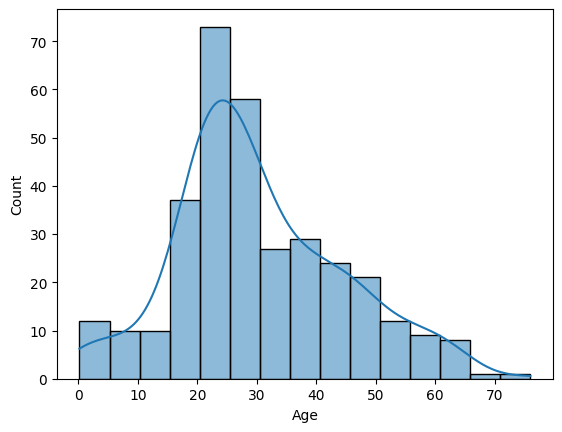

In [19]:
import seaborn as sns

sns.histplot(df['Age'], kde=True)

In [24]:
df['Age_Mean'] = df['Age'].fillna(df['Age'].mean())

In [26]:
df[['Age', 'Age_Mean']]

,Age,Age_Mean
0,34.5,34.50000
1,47.0,47.00000
2,62.0,62.00000
3,27.0,27.00000
4,22.0,22.00000
...,...,...
413,NaN,30.27259
414,39.0,39.00000
415,38.5,38.50000
416,NaN,30.27259


### 2. Median Imputation method

#### It will work well when we have outliers in our dataset

In [30]:
df['Age_Median'] = df['Age'].fillna(df['Age'].median())

In [32]:
df[['Age', 'Age_Median']]

,Age,Age_Median
0,34.5,34.5
1,47.0,47.0
2,62.0,62.0
3,27.0,27.0
4,22.0,22.0
...,...,...
413,NaN,27.0
414,39.0,39.0
415,38.5,38.5
416,NaN,27.0


### 3. Mode imputation method

#### It will work with categorical data

In [37]:
df[df['Cabin'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Mean,Age_Meadian,Age_Median,Age_Mode
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,34.50000,34.5,34.5,34.5
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,47.00000,47.0,47.0,47.0
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,62.00000,62.0,62.0,62.0
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,27.00000,27.0,27.0,27.0
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,22.00000,22.0,22.0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S,28.00000,28.0,28.0,28.0
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,30.27259,27.0,27.0,NaN
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,38.50000,38.5,38.5,38.5
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,30.27259,27.0,27.0,NaN


In [38]:
df['Cabin'].unique()

array([nan, 'B45', 'E31', 'B57 B59 B63 B66', 'B36', 'A21', 'C78', 'D34',
       'D19', 'A9', 'D15', 'C31', 'C23 C25 C27', 'F G63', 'B61', 'C53',
       'D43', 'C130', 'C132', 'C101', 'C55 C57', 'B71', 'C46', 'C116',
       'F', 'A29', 'G6', 'C6', 'C28', 'C51', 'E46', 'C54', 'C97', 'D22',
       'B10', 'F4', 'E45', 'E52', 'D30', 'B58 B60', 'E34', 'C62 C64',
       'A11', 'B11', 'C80', 'F33', 'C85', 'D37', 'C86', 'D21', 'C89',
       'F E46', 'A34', 'D', 'B26', 'C22 C26', 'B69', 'C32', 'B78',
       'F E57', 'F2', 'A18', 'C106', 'B51 B53 B55', 'D10 D12', 'E60',
       'E50', 'E39 E41', 'B52 B54 B56', 'C39', 'B24', 'D28', 'B41', 'C7',
       'D40', 'D38', 'C105'], dtype=object)

In [53]:
mode_value = df[df['Cabin'].notna()]['Cabin'].mode()[0]

mode_value

'B57 B59 B63 B66'

In [55]:
df['Cabin_update'] = df['Cabin'].fillna(mode_value)

In [56]:
df[['Cabin', 'Cabin_update']]

,Cabin,Cabin_update
0,NaN,B57 B59 B63 B66
1,NaN,B57 B59 B63 B66
2,NaN,B57 B59 B63 B66
3,NaN,B57 B59 B63 B66
4,NaN,B57 B59 B63 B66
...,...,...
413,NaN,B57 B59 B63 B66
414,C105,C105
415,NaN,B57 B59 B63 B66
416,NaN,B57 B59 B63 B66
